# Sequence Simulation

Manual Ba-137 sequence notebook.

- Enter the sequence directly as driven pulses and optional `wait` steps.
- `sequence_initial_wait_us` and `cpmg_initial_wait_us` add a free-evolution wait immediately after state preparation and before the first driven pulse.
- `simulation_mode = "ideal"` skips Monte Carlo and keeps only deterministic evolution.
- `use_line_signal` controls the repeatable line-signal contribution in either mode.
- Leave `line_signal_noise_std_g = 0.0` if line signal should not be sampled as stochastic noise.
- Wait-step format: `{"kind": "wait", "coupling": (i, j), "duration_us": ...}`.


In [12]:
import importlib
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import numpy as np

import sequence_simulation_helpers as ssh
ssh = importlib.reload(ssh)

from sequence_simulation_helpers import (
    basis_state,
    default_line_noise_model,
    display_records,
    plot_populations,
    prepare_sequence_data,
    pulse_summary_records,
    run_sequence_simulation,
    summarize_simulation_result,
    wrap_frame,
)

np.set_printoptions(precision=6, suppress=True)

def prepend_initial_wait_step(sequence_steps, initial_wait_us=0.0, initial_wait_coupling=None, label="sequence"):
    wait_us = float(initial_wait_us)
    copied_steps = [dict(step) for step in sequence_steps]
    if wait_us <= 0.0:
        return copied_steps

    coupling = initial_wait_coupling
    if coupling is None:
        for step in copied_steps:
            if "coupling" in step and step["coupling"] is not None:
                coupling = step["coupling"]
                break
    if coupling is None:
        raise ValueError(f"{label} initial wait requires an explicit coupling or at least one sequence step with a coupling")

    wait_step = {
        "kind": "wait",
        "coupling": ssh.coupling_key(coupling),
        "duration_us": wait_us,
    }
    return [wait_step] + copied_steps


def format_angle_over_pi(angle_rad, decimals=2):
    return f"{float(angle_rad) / np.pi:.{decimals}f}π"


def plot_sequence_timeline(prepared_sequence, mappings, line_model=None, use_line_signal=True, line_reference="start", title_prefix="Sequence timeline", field_num_points=2000):
    steps = prepared_sequence["steps"]
    if not steps:
        raise ValueError("prepared_sequence must contain at least one step")

    durations_us = np.asarray(prepared_sequence["durations_us"], dtype=float)
    timing_us = np.asarray(prepared_sequence["timing_us"], dtype=float)
    sensitivities_mhz_per_g = np.asarray(prepared_sequence["pulse_sensitivities_mhz_per_g"], dtype=float)
    total_time_us = float(np.sum(durations_us))
    if total_time_us <= 0.0:
        raise ValueError("Total sequence time must be positive")

    time_plot_us = np.linspace(0.0, total_time_us, max(int(field_num_points), 2))
    if use_line_signal:
        line_field_mG = 1e3 * ssh.line_field_relative_G(time_plot_us * 1e-6, line_model=line_model)
        _, _, line_reference_times_s = ssh.compute_line_phase_corrections(
            durations_us,
            sensitivities_mhz_per_g,
            line_model=line_model,
            t_ref=line_reference,
            enabled=True,
        )
        line_reference_times_us = 1e6 * np.asarray(line_reference_times_s, dtype=float)
        line_reference_fields_mG = 1e3 * ssh.line_field_relative_G(line_reference_times_s, line_model=line_model)
    else:
        line_field_mG = np.zeros_like(time_plot_us)
        line_reference_times_us = timing_us[:, 0]
        line_reference_fields_mG = np.zeros(len(steps), dtype=float)

    unique_couplings = []
    for coupling in prepared_sequence["couplings"]:
        normalized = ssh.coupling_key(coupling)
        if normalized not in unique_couplings:
            unique_couplings.append(normalized)
    coupling_to_y = {coupling: index for index, coupling in enumerate(unique_couplings)}

    fig_width = max(10.0, 20)
    fig, ax_field = plt.subplots(figsize=(fig_width, 6.0))
    ax_control = ax_field.twinx()

    ax_field.plot(time_plot_us, line_field_mG, color="#1f4e79", linewidth=2.0, label="Line field")
    ax_field.axhline(0.0, color="#1f4e79", linestyle="--", linewidth=1.0, alpha=0.5)
    ax_field.plot(line_reference_times_us, line_reference_fields_mG, "o", color="#d62728", markersize=4, label=f"Line reference ({line_reference})")
    ax_field.set_xlabel("Time (us)")
    ax_field.set_ylabel("Line field ΔB relative to t=0 (mG)")
    ax_field.grid(True, axis="x", alpha=0.25)

    cmap = plt.get_cmap("tab10")
    for step_index, step in enumerate(steps):
        start_us, end_us = timing_us[step_index]
        duration_us = end_us - start_us
        coupling = ssh.coupling_key(step["coupling"])
        y_center = coupling_to_y[coupling]
        color = cmap(y_center % 10)

        if step["kind"] == "pulse":
            rect = Rectangle((start_us, y_center - 0.32), duration_us, 0.64, facecolor=color, edgecolor=color, alpha=0.32, linewidth=1.4)
            ax_control.add_patch(rect)
            annotation = f"θ={format_angle_over_pi(step['theta'])}\nφ={format_angle_over_pi(step['programmed_phase'])}"
            ax_control.text(
                start_us + 0.5 * duration_us,
                y_center,
                annotation,
                ha="center",
                va="center",
                fontsize=7,
                rotation=90,
                color="black",
                clip_on=True,
            )
        else:
            rect = Rectangle((start_us, y_center - 0.18), duration_us, 0.36, facecolor="none", edgecolor="#444444", linestyle="--", linewidth=1.2)
            ax_control.add_patch(rect)
            if duration_us >= 0.05 * total_time_us:
                ax_control.text(
                    start_us + 0.5 * duration_us,
                    y_center,
                    f"wait\n{duration_us:.1f} us",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="#444444",
                    clip_on=True,
                )

        ax_field.axvline(start_us, color="#bbbbbb", linewidth=0.7, alpha=0.35)
    ax_field.axvline(total_time_us, color="#bbbbbb", linewidth=0.7, alpha=0.35)

    ax_control.set_ylim(-0.8, len(unique_couplings) - 0.2 if unique_couplings else 0.8)
    ax_control.set_yticks(np.arange(len(unique_couplings), dtype=float))
    ax_control.set_yticklabels([ssh.format_coupling_label(coupling, mappings) for coupling in unique_couplings])
    ax_control.set_ylabel("Control coupling")
    ax_control.grid(False)

    title_suffix = "line signal on" if use_line_signal else "line signal off"
    ax_field.set_title(f"{title_prefix} ({title_suffix}, reference={line_reference})")
    ax_field.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


In [13]:
# Manual sequence configuration.
dimension = 4

mappings = {
    0: "0",
    1: "[4, -2]",
    2: "[3, 1]",
    3: "[4, -1]",
    4: "[3, 0]",
    5: "[3, 2]",
    6: "[4, 0]",
    7: "[2, -2]",
    8: "[2, 0]",
    9: "[2, 2]",
    10: "[4, 1]",
    11: "[3, -1]",
    12: "[1, 1]",
    13: "[2, -1]",
    14: "[1, -1]",
    15: "[2, 1]",
}

# Replace this with the sequence you want to test.
sequence_steps = [
    {"coupling": (0, 1), "theta": np.pi / 2.0, "phi": np.pi / 2.0},
    {"kind": "wait", "coupling": (0, 2), "duration_us": 50.0},
    {"coupling": (0, 2), "theta": 2.0 * np.arcsin(np.sqrt(1.0 / 3.0)), "phi": np.pi / 2.0},
    {"coupling": (0, 3), "theta": 2.0 * np.arcsin(np.sqrt(1.0 / 4.0)), "phi": np.pi / 2.0},
]

# Ramsey-style example on one coupling:
# sequence_steps = [
#     {"coupling": (0, 1), "theta": np.pi / 2.0, "phi": 0.0},
#     {"kind": "wait", "coupling": (0, 1), "duration_us": 200.0},
#     {"coupling": (0, 1), "theta": np.pi / 2.0, "phi": 0.0},
# ]

# Optional free-evolution wait inserted after the initial state is prepared and before the sequence starts.
# Leave sequence_initial_wait_coupling = None to reuse the first step coupling.
sequence_initial_wait_us = 0.0
sequence_initial_wait_coupling = None
sequence_steps_with_initial_wait = prepend_initial_wait_step(
    sequence_steps,
    initial_wait_us=sequence_initial_wait_us,
    initial_wait_coupling=sequence_initial_wait_coupling,
    label="manual sequence",
)

initial_state_index = 0
initial_state = basis_state(initial_state_index, dimension)

# Optional final virtual-Z frame.
final_frame = np.zeros(dimension, dtype=float)
apply_final_frame = False

# Optional target state for fidelity reporting.
# target_state = basis_state(3, dimension)
target_state = None


In [14]:
# Calibration and simulation settings.
transition_strengths_file = r"Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\Transition_strengths_4p209.txt"
sensitivity_matrix_file = r"Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\sensitivities_4p2079.txt"
line_signal_param_file = r"Z:\\Lab Data\\Line_signal_fitted_params\\line_signal_fit_params_20260220.txt"

reference_pi_times_us = np.array([23.9, 25.491, 98.8, 25.836, 32.11], dtype=float)
reference_strength_indices = [(21, 2), (14, 0), (5, 2), (16, 4), (15, 4)]

default_pi_time_us = 20.0
pi_time_by_coupling_us = {}
per_pulse_pi_time_us = None
pulse_sensitivities_mhz_per_g = None

simulation_mode = "ideal"  # "ideal" or "monte_carlo"
use_line_signal = True
line_model = default_line_noise_model(param_file=line_signal_param_file)
line_reference = "start"

# Monte Carlo settings. Ignored in ideal mode.
num_shots = 200
rng_seed = int(np.random.SeedSequence().entropy)
calibration_scale = 1.0
magnetic_scale = 1.0
laser_scale = 1.0
calibration_noise_hwhm_hz = 15.0
calibration_noise_sigma_hz = 0.0
magnetic_field_std_g = 11.13e-6
laser_gaussian_T_s = 2 * np.pi * 2206.8675860990334e-6
laser_lorentzian_L_s = 2 * np.pi * 3353.155420102816e-6
voigt_x_min_hz = -1000.0
voigt_x_max_hz = 1000.0
voigt_num_points = 100000
rabi_frequency_std_fraction = 0.037

# Keep this at 0.0 if line signal is treated as deterministic only.
line_signal_noise_std_g = 0.0


Step summary


,step,kind,coupling,transition,theta_rad,theta_over_pi,phase_rad,pi_time_us,duration_us,t_start_us,t_end_us,sensitivity_MHz_per_G,line_phase_rad,line_detuning_MHz
0,1,pulse,"0 <-> [4, -2]","0 -> [4, -2]",1.570796,0.500000,1.570796,23.900000,11.950000,0.000000,11.950000,-3.420181,-0.000000,-0.000000e+00
1,2,wait,"0 <-> [3, 1]","0 -> [3, 1]",0.000000,0.000000,0.000000,NaN,50.000000,11.950000,61.950000,2.138519,0.000016,4.206408e-07
2,3,pulse,"0 <-> [3, 1]","0 -> [3, 1]",1.230959,0.391827,1.570796,32.439255,12.710562,61.950000,74.660562,2.138519,0.000391,1.889512e-06
3,4,pulse,"0 <-> [4, -1]","0 -> [4, -1]",1.047198,0.333333,1.570796,33.164799,11.054933,74.660562,85.715495,-2.466303,-0.000639,-2.532682e-06



Simulation summary
mode = ideal
use_line_signal = True
step_count = 4
driven_pulse_count = 3
wait_count = 1
total_sequence_time_us = 85.715495
line_phase_offsets_rad = [-0.        0.000016  0.000391 -0.000639]
line_detunings_mhz = [-0.        0.        0.000002 -0.000003]


,state_index,state_label,mean_population,std_population
0,0,0,0.250000,0.0
1,1,"[4, -2]",0.500000,0.0
2,2,"[3, 1]",0.166667,0.0
3,3,"[4, -1]",0.083333,0.0


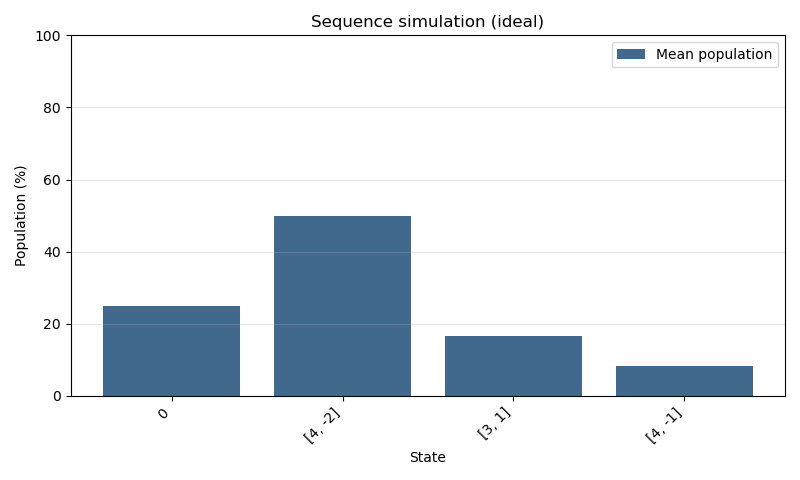

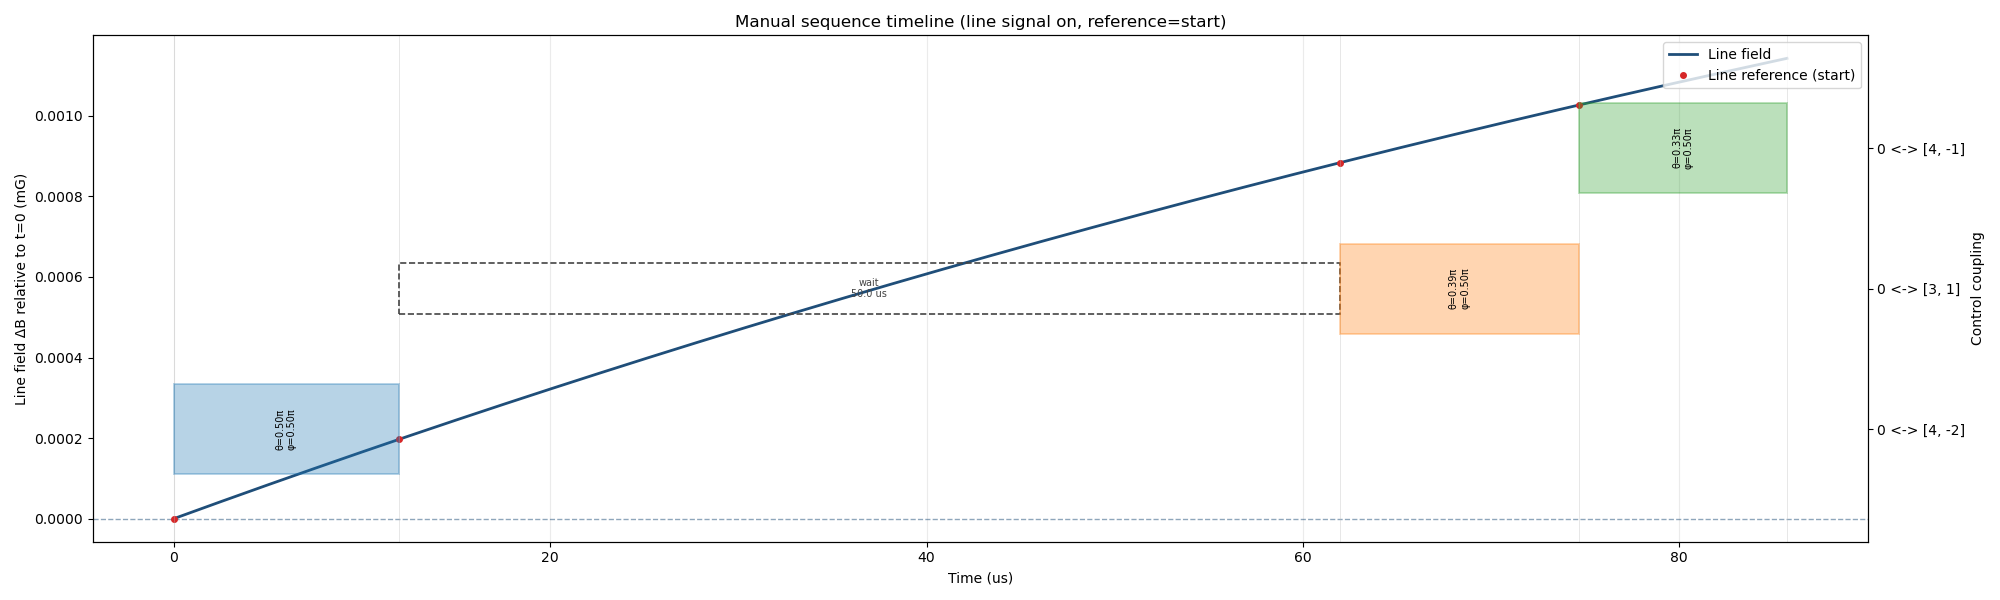

In [15]:
prepared_sequence = prepare_sequence_data(
    sequence_steps=sequence_steps_with_initial_wait,
    dimension=dimension,
    mappings=mappings,
    default_pi_time_us=default_pi_time_us,
    pi_time_by_coupling_us=pi_time_by_coupling_us,
    per_pulse_pi_time_us=per_pulse_pi_time_us,
    pulse_sensitivities_mhz_per_g=pulse_sensitivities_mhz_per_g,
    transition_strengths_file=transition_strengths_file,
    sensitivity_matrix_file=sensitivity_matrix_file,
    reference_pi_times_us=reference_pi_times_us,
    reference_strength_indices=reference_strength_indices,
)

simulation_result = run_sequence_simulation(
    prepared_sequence=prepared_sequence,
    initial_state=initial_state,
    final_frame=wrap_frame(final_frame) if final_frame is not None else None,
    apply_final_frame=apply_final_frame,
    simulation_mode=simulation_mode,
    use_line_signal=use_line_signal,
    line_model=line_model,
    line_reference=line_reference,
    num_shots=num_shots,
    rng_seed=rng_seed,
    calibration_scale=calibration_scale,
    magnetic_scale=magnetic_scale,
    laser_scale=laser_scale,
    calibration_noise_hwhm_hz=calibration_noise_hwhm_hz,
    calibration_noise_sigma_hz=calibration_noise_sigma_hz,
    magnetic_field_std_g=magnetic_field_std_g,
    laser_gaussian_T_s=laser_gaussian_T_s,
    laser_lorentzian_L_s=laser_lorentzian_L_s,
    voigt_x_min_hz=voigt_x_min_hz,
    voigt_x_max_hz=voigt_x_max_hz,
    voigt_num_points=voigt_num_points,
    rabi_frequency_std_fraction=rabi_frequency_std_fraction,
    line_signal_noise_std_g=line_signal_noise_std_g,
    target_state=target_state,
)

print("Step summary")
display_records(pulse_summary_records(prepared_sequence, simulation_result, mappings))

print("\nSimulation summary")
summarize_simulation_result(simulation_result, prepared_sequence, mappings)
plot_populations(simulation_result, mappings)
plot_sequence_timeline(
    prepared_sequence,
    mappings,
    line_model=line_model,
    use_line_signal=use_line_signal,
    line_reference=line_reference,
    title_prefix="Manual sequence timeline",
)


# CPMG sequence simulation

- `cpmg_pi_pulse_spacings_us` is now treated as the explicit wait inserted between every neighboring pulse.
- `cpmg_initial_wait_us` adds a free-evolution wait after state preparation and before the first `pi/2` pulse.
- The same configured wait is used after the first `pi/2`, between successive `pi` pulses, and before the final `pi/2`.
- `cpmg_final_pi_half_phase_rad` is fixed during the sweep. The notebook now scans only the pulse wait and plots the population of state `0` versus `1 / (2 * wait)`.
- Default phase convention here is `pi/2_x - pi_y ... pi_y - pi/2_phi`.


In [16]:
# CPMG-specific helpers stay in the notebook. The generic sequence simulation remains in sequence_simulation_helpers.py.

def resolve_coupling_pi_time_us(coupling, mappings, default_pi_time_us=20.0, pi_time_by_coupling_us=None, transition_strengths_file=None, reference_pi_times_us=None, reference_strength_indices=None):
    coupling = ssh.coupling_key(coupling)
    if transition_strengths_file is not None:
        if reference_pi_times_us is None or reference_strength_indices is None:
            raise ValueError("reference_pi_times_us and reference_strength_indices are required when using transition_strengths_file")
        transition = ssh.build_transitions_list(mappings, [coupling])[0]
        strength_matrix = ssh.load_csv_matrix(str(transition_strengths_file))
        pi_time_matrix = ssh.compute_pi_time_matrix(strength_matrix, reference_pi_times_us, reference_strength_indices)
        return float(ssh.values_from_matrix([transition], pi_time_matrix)[0])
    return float(ssh.resolve_pi_times_us([coupling], default_pi_time_us, pi_time_by_coupling_us, None)[0])


def build_cpmg_sequence_steps(coupling, mappings, num_pi_pulses, pi_pulse_spacing_us, final_pi_half_phase_rad, pi_time_us=None, initial_pi_half_phase_rad=0.0, pi_pulse_phase_rad=np.pi / 2.0, initial_pi_half_theta_rad=np.pi / 2.0, pi_pulse_theta_rad=np.pi, final_pi_half_theta_rad=np.pi / 2.0, initial_wait_us=0.0, default_pi_time_us=20.0, pi_time_by_coupling_us=None, transition_strengths_file=None, reference_pi_times_us=None, reference_strength_indices=None):
    coupling = ssh.coupling_key(coupling)
    num_pi_pulses = int(num_pi_pulses)
    if num_pi_pulses < 1:
        raise ValueError("num_pi_pulses must be at least 1 for CPMG")

    pi_pulse_spacing_us = float(pi_pulse_spacing_us)
    if pi_pulse_spacing_us <= 0.0:
        raise ValueError("pi_pulse_spacing_us must be positive")

    if pi_time_us is None:
        pi_time_us = resolve_coupling_pi_time_us(
            coupling,
            mappings,
            default_pi_time_us=default_pi_time_us,
            pi_time_by_coupling_us=pi_time_by_coupling_us,
            transition_strengths_file=transition_strengths_file,
            reference_pi_times_us=reference_pi_times_us,
            reference_strength_indices=reference_strength_indices,
        )
    pi_time_us = float(pi_time_us)

    inter_pulse_wait_us = pi_pulse_spacing_us

    sequence_steps = [
        {
            "kind": "pulse",
            "coupling": coupling,
            "theta": float(initial_pi_half_theta_rad),
            "phi": float(initial_pi_half_phase_rad),
            "pi_time_us": pi_time_us,
        }
    ]
    if inter_pulse_wait_us > 0.0:
        sequence_steps.append({"kind": "wait", "coupling": coupling, "duration_us": inter_pulse_wait_us, "pi_time_us": pi_time_us})

    for pulse_index in range(num_pi_pulses):
        sequence_steps.append(
            {
                "kind": "pulse",
                "coupling": coupling,
                "theta": float(pi_pulse_theta_rad),
                "phi": float(pi_pulse_phase_rad),
                "pi_time_us": pi_time_us,
            }
        )
        if inter_pulse_wait_us > 0.0:
            sequence_steps.append({"kind": "wait", "coupling": coupling, "duration_us": inter_pulse_wait_us, "pi_time_us": pi_time_us})

    sequence_steps.append(
        {
            "kind": "pulse",
            "coupling": coupling,
            "theta": float(final_pi_half_theta_rad),
            "phi": float(final_pi_half_phase_rad),
            "pi_time_us": pi_time_us,
        }
    )
    sequence_steps = prepend_initial_wait_step(
        sequence_steps,
        initial_wait_us=initial_wait_us,
        initial_wait_coupling=coupling,
        label="CPMG sequence",
    )
    return sequence_steps, {
        "coupling": coupling,
        "pi_time_us": pi_time_us,
        "pi_pulse_spacing_us": pi_pulse_spacing_us,
        "edge_wait_us": inter_pulse_wait_us,
        "middle_wait_us": inter_pulse_wait_us,
        "final_edge_wait_us": inter_pulse_wait_us,
        "inter_pulse_wait_us": inter_pulse_wait_us,
        "initial_wait_us": float(initial_wait_us),
        "num_pi_pulses": num_pi_pulses,
    }


def run_cpmg_spacing_sweep(coupling, mappings, dimension, initial_state, final_pi_half_phase_rad, pi_pulse_spacings_us, num_pi_pulses=1, measured_state_index=0, pi_time_us=None, cpmg_sensitivity_mhz_per_g=None, initial_pi_half_phase_rad=0.0, pi_pulse_phase_rad=np.pi / 2.0, initial_pi_half_theta_rad=np.pi / 2.0, pi_pulse_theta_rad=np.pi, final_pi_half_theta_rad=np.pi / 2.0, initial_wait_us=0.0, final_frame=None, apply_final_frame=False, simulation_mode="ideal", use_line_signal=True, line_model=None, line_reference="start", default_pi_time_us=20.0, pi_time_by_coupling_us=None, transition_strengths_file=None, sensitivity_matrix_file=None, reference_pi_times_us=None, reference_strength_indices=None, num_shots=200, rng_seed=None, calibration_scale=1.0, magnetic_scale=1.0, laser_scale=1.0, calibration_noise_hwhm_hz=15.0, calibration_noise_sigma_hz=0.0, magnetic_field_std_g=11.13e-6, laser_gaussian_T_s=2 * np.pi * 2206.8675860990334e-6, laser_lorentzian_L_s=2 * np.pi * 3353.155420102816e-6, voigt_x_min_hz=-1000.0, voigt_x_max_hz=1000.0, voigt_num_points=100000, rabi_frequency_std_fraction=0.037, line_signal_noise_std_g=0.0, target_state=None):
    coupling = ssh.coupling_key(coupling)
    final_pi_half_phase_rad = float(final_pi_half_phase_rad)
    pi_pulse_spacings_us = np.asarray(pi_pulse_spacings_us, dtype=float)
    initial_state = ssh.normalize_state(initial_state)

    if pi_pulse_spacings_us.ndim != 1:
        raise ValueError("pi_pulse_spacings_us must be one-dimensional")

    measured_state_index = int(measured_state_index)
    if not (0 <= measured_state_index < int(dimension)):
        raise ValueError("measured_state_index is out of range")

    resolved_pi_time_us = float(pi_time_us) if pi_time_us is not None else resolve_coupling_pi_time_us(
        coupling,
        mappings,
        default_pi_time_us=default_pi_time_us,
        pi_time_by_coupling_us=pi_time_by_coupling_us,
        transition_strengths_file=transition_strengths_file,
        reference_pi_times_us=reference_pi_times_us,
        reference_strength_indices=reference_strength_indices,
    )

    population_by_spacing = np.zeros((len(pi_pulse_spacings_us), int(dimension)), dtype=float)
    std_population_by_spacing = np.zeros_like(population_by_spacing)
    total_time_us = np.zeros(len(pi_pulse_spacings_us), dtype=float)
    sequence_examples = {}
    prepared_examples = {}

    for spacing_index, spacing_us in enumerate(pi_pulse_spacings_us):
        sequence_steps, sequence_metadata = build_cpmg_sequence_steps(
            coupling=coupling,
            mappings=mappings,
            num_pi_pulses=num_pi_pulses,
            pi_pulse_spacing_us=float(spacing_us),
            final_pi_half_phase_rad=final_pi_half_phase_rad,
            pi_time_us=resolved_pi_time_us,
            initial_pi_half_phase_rad=initial_pi_half_phase_rad,
            pi_pulse_phase_rad=pi_pulse_phase_rad,
            initial_pi_half_theta_rad=initial_pi_half_theta_rad,
            pi_pulse_theta_rad=pi_pulse_theta_rad,
            final_pi_half_theta_rad=final_pi_half_theta_rad,
            initial_wait_us=initial_wait_us,
            default_pi_time_us=default_pi_time_us,
            pi_time_by_coupling_us=pi_time_by_coupling_us,
            transition_strengths_file=transition_strengths_file,
            reference_pi_times_us=reference_pi_times_us,
            reference_strength_indices=reference_strength_indices,
        )
        per_pulse_pi_times_us = np.full(num_pi_pulses + 2, resolved_pi_time_us, dtype=float)
        per_step_sensitivities = None
        if cpmg_sensitivity_mhz_per_g is not None:
            per_step_sensitivities = np.full(len(sequence_steps), float(cpmg_sensitivity_mhz_per_g), dtype=float)

        prepared_sequence = ssh.prepare_sequence_data(
            sequence_steps=sequence_steps,
            dimension=dimension,
            mappings=mappings,
            default_pi_time_us=default_pi_time_us,
            pi_time_by_coupling_us=pi_time_by_coupling_us,
            per_pulse_pi_time_us=per_pulse_pi_times_us,
            pulse_sensitivities_mhz_per_g=per_step_sensitivities,
            transition_strengths_file=transition_strengths_file,
            sensitivity_matrix_file=sensitivity_matrix_file,
            reference_pi_times_us=reference_pi_times_us,
            reference_strength_indices=reference_strength_indices,
        )
        result = ssh.run_sequence_simulation(
            prepared_sequence=prepared_sequence,
            initial_state=initial_state,
            final_frame=final_frame,
            apply_final_frame=apply_final_frame,
            simulation_mode=simulation_mode,
            use_line_signal=use_line_signal,
            line_model=line_model,
            line_reference=line_reference,
            num_shots=num_shots,
            rng_seed=None if rng_seed is None else int(rng_seed) + 100000 * spacing_index,
            calibration_scale=calibration_scale,
            magnetic_scale=magnetic_scale,
            laser_scale=laser_scale,
            calibration_noise_hwhm_hz=calibration_noise_hwhm_hz,
            calibration_noise_sigma_hz=calibration_noise_sigma_hz,
            magnetic_field_std_g=magnetic_field_std_g,
            laser_gaussian_T_s=laser_gaussian_T_s,
            laser_lorentzian_L_s=laser_lorentzian_L_s,
            voigt_x_min_hz=voigt_x_min_hz,
            voigt_x_max_hz=voigt_x_max_hz,
            voigt_num_points=voigt_num_points,
            rabi_frequency_std_fraction=rabi_frequency_std_fraction,
            line_signal_noise_std_g=line_signal_noise_std_g,
            target_state=target_state,
        )
        population_by_spacing[spacing_index, :] = np.asarray(result["mean_populations"], dtype=float)
        std_population_by_spacing[spacing_index, :] = np.asarray(result["std_populations"], dtype=float)
        total_time_us[spacing_index] = float(np.sum(prepared_sequence["durations_us"]))
        if spacing_index == 0:
            sequence_examples["first"] = {"sequence_steps": sequence_steps, "metadata": sequence_metadata}
            prepared_examples["first"] = prepared_sequence

    measured_state_population = population_by_spacing[:, measured_state_index]
    measured_state_std = std_population_by_spacing[:, measured_state_index]
    inverse_half_wait_hz = 1e6 / (2.0 * pi_pulse_spacings_us)
    return {
        "coupling": coupling,
        "dimension": int(dimension),
        "num_pi_pulses": int(num_pi_pulses),
        "nominal_pi_time_us": resolved_pi_time_us,
        "final_pi_half_phase_rad": final_pi_half_phase_rad,
        "pi_pulse_spacings_us": pi_pulse_spacings_us,
        "inverse_half_wait_hz": inverse_half_wait_hz,
        "population_by_spacing": population_by_spacing,
        "std_population_by_spacing": std_population_by_spacing,
        "measured_state_index": measured_state_index,
        "measured_state_label": ssh.format_state_label(measured_state_index, mappings),
        "measured_state_population": measured_state_population,
        "measured_state_std": measured_state_std,
        "total_time_us": total_time_us,
        "sequence_examples": sequence_examples,
        "prepared_examples": prepared_examples,
        "simulation_mode": simulation_mode,
        "use_line_signal": bool(use_line_signal),
    }


def plot_cpmg_population_vs_wait(sweep_result, title_prefix="CPMG state-0 population"):
    inverse_half_wait_hz = np.asarray(sweep_result["inverse_half_wait_hz"], dtype=float)
    measured_population = 100.0 * np.asarray(sweep_result["measured_state_population"], dtype=float)
    measured_std = 100.0 * np.asarray(sweep_result["measured_state_std"], dtype=float)

    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    ax.plot(inverse_half_wait_hz, measured_population, "o-", linewidth=1.5, markersize=5.0)
    if np.any(measured_std > 0):
        ax.errorbar(inverse_half_wait_hz, measured_population, yerr=measured_std, fmt="none", ecolor="black", elinewidth=1.0, capsize=3)
    ax.set_xlabel("1 / (2 * pulse wait) (Hz)")
    ax.set_ylabel(f"Population of state {sweep_result['measured_state_label']} (%)")
    ax.set_title(
        f"{title_prefix}: state {sweep_result['measured_state_label']}, "
        f"N={sweep_result['num_pi_pulses']}, mode={sweep_result['simulation_mode']}"
    )
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def fit_phase_scan_cosine(phases_rad, values):
    phases_rad = np.asarray(phases_rad, dtype=float)
    values = np.asarray(values, dtype=float)
    if phases_rad.ndim != 1 or values.ndim != 1:
        raise ValueError("phases_rad and values must be one-dimensional")
    if len(phases_rad) != len(values):
        raise ValueError("phases_rad and values must have the same length")
    if len(phases_rad) < 3:
        raise ValueError("At least three phase points are required for a cosine fit")

    fit_phases_rad = phases_rad
    fit_values = values
    if len(phases_rad) > 3 and np.isclose(np.mod(phases_rad[-1] - phases_rad[0], 2.0 * np.pi), 0.0, atol=1e-9):
        fit_phases_rad = phases_rad[:-1]
        fit_values = values[:-1]

    design_matrix = np.column_stack(
        [
            np.ones(len(fit_phases_rad), dtype=float),
            np.cos(fit_phases_rad),
            np.sin(fit_phases_rad),
        ]
    )
    coefficients, _, _, _ = np.linalg.lstsq(design_matrix, fit_values, rcond=None)
    offset, cos_coefficient, sin_coefficient = coefficients
    amplitude = float(np.hypot(cos_coefficient, sin_coefficient))
    phase_rad = ssh.wrap_pi(np.arctan2(sin_coefficient, cos_coefficient))

    fitted_values = offset + amplitude * np.cos(phases_rad - phase_rad)
    residuals = values - fitted_values
    ss_res = float(np.sum(np.square(residuals)))
    ss_tot = float(np.sum(np.square(values - np.mean(values))))
    r_squared = np.nan if np.isclose(ss_tot, 0.0) else 1.0 - ss_res / ss_tot
    return {
        "offset": float(offset),
        "amplitude": amplitude,
        "phase_rad": float(phase_rad),
        "phase_over_pi": float(phase_rad / np.pi),
        "fitted_values": np.asarray(fitted_values, dtype=float),
        "residuals": np.asarray(residuals, dtype=float),
        "r_squared": float(r_squared),
    }


def fit_cpmg_spacing_phases(sweep_result, unwrap=True, sort_by_inverse_spacing=True):
    final_pi_half_phases_rad = np.asarray(sweep_result["final_pi_half_phases_rad"], dtype=float)
    pi_pulse_spacings_us = np.asarray(sweep_result["pi_pulse_spacings_us"], dtype=float)
    measured_state_population = np.asarray(sweep_result["measured_state_population"], dtype=float)

    expected_shape = (len(pi_pulse_spacings_us), len(final_pi_half_phases_rad))
    if measured_state_population.shape != expected_shape:
        raise ValueError(
            "measured_state_population has incompatible shape: "
            f"expected {expected_shape}, received {measured_state_population.shape}"
        )

    fit_results = []
    for spacing_index, spacing_us in enumerate(pi_pulse_spacings_us):
        fit_result = fit_phase_scan_cosine(final_pi_half_phases_rad, measured_state_population[spacing_index, :])
        fit_result["spacing_us"] = float(spacing_us)
        fit_result["inverse_half_spacing_per_us"] = float(1.0 / (2.0 * float(spacing_us)))
        fit_results.append(fit_result)

    order = np.arange(len(fit_results), dtype=int)
    if sort_by_inverse_spacing:
        order = np.argsort([fit_results[index]["inverse_half_spacing_per_us"] for index in order])

    wrapped_phase_rad = np.array([fit_results[index]["phase_rad"] for index in order], dtype=float)
    unwrapped_phase_rad = np.unwrap(wrapped_phase_rad) if unwrap else wrapped_phase_rad.copy()
    spacing_sorted_us = np.array([fit_results[index]["spacing_us"] for index in order], dtype=float)
    inverse_half_spacing_sorted_per_us = np.array(
        [fit_results[index]["inverse_half_spacing_per_us"] for index in order],
        dtype=float,
    )
    amplitude_sorted = np.array([fit_results[index]["amplitude"] for index in order], dtype=float)
    offset_sorted = np.array([fit_results[index]["offset"] for index in order], dtype=float)
    r_squared_sorted = np.array([fit_results[index]["r_squared"] for index in order], dtype=float)

    fit_records = []
    for index, spacing_us in enumerate(spacing_sorted_us):
        fit_records.append(
            {
                "spacing_us": float(spacing_us),
                "inverse_half_spacing_per_us": float(inverse_half_spacing_sorted_per_us[index]),
                "phase_rad": float(unwrapped_phase_rad[index]),
                "phase_over_pi": float(unwrapped_phase_rad[index] / np.pi),
                "wrapped_phase_rad": float(wrapped_phase_rad[index]),
                "wrapped_phase_over_pi": float(wrapped_phase_rad[index] / np.pi),
                "amplitude": float(amplitude_sorted[index]),
                "offset": float(offset_sorted[index]),
                "r_squared": float(r_squared_sorted[index]),
            }
        )

    return {
        "measured_state_label": sweep_result["measured_state_label"],
        "num_pi_pulses": int(sweep_result["num_pi_pulses"]),
        "simulation_mode": sweep_result["simulation_mode"],
        "spacing_us": spacing_sorted_us,
        "inverse_half_spacing_per_us": inverse_half_spacing_sorted_per_us,
        "wrapped_phase_rad": wrapped_phase_rad,
        "wrapped_phase_over_pi": wrapped_phase_rad / np.pi,
        "phase_rad": unwrapped_phase_rad,
        "phase_over_pi": unwrapped_phase_rad / np.pi,
        "amplitude": amplitude_sorted,
        "offset": offset_sorted,
        "r_squared": r_squared_sorted,
        "fit_records": fit_records,
    }


def plot_cpmg_fitted_phase_vs_inverse_spacing(phase_fit_result, title_prefix="CPMG fitted phase"):
    inverse_half_spacing_per_s = np.asarray(phase_fit_result["inverse_half_spacing_per_us"], dtype=float)*1e6
    phase_over_pi = np.asarray(phase_fit_result["wrapped_phase_over_pi"], dtype=float)

    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    ax.plot(inverse_half_spacing_per_s, phase_over_pi, "o-", linewidth=1.5, markersize=5.0)
    ax.set_xlabel("1 / (2 * pulse wait) (Hz)")
    ax.set_ylabel("Fitted phase / pi")
    ax.set_title(
        f"{title_prefix}: state {phase_fit_result['measured_state_label']}, "
        f"N={phase_fit_result['num_pi_pulses']}, mode={phase_fit_result['simulation_mode']}"
    )
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [32]:
# CPMG configuration.

mappings = {
    0: "0",
    1: "[3, -1]"
}

cpmg_coupling = (0, 1)
cpmg_num_pi_pulses = 3
cpmg_measured_state_index = 0

cpmg_initial_pi_half_phase_rad = 0.0
cpmg_pi_pulse_phase_rad = np.pi/2
cpmg_initial_wait_us = 10467

cpmg_final_pi_half_phase_rad = 0.0
# cpmg_pi_pulse_spacings_us = np.linspace(1000.0, 10000.0, 101)
cpmg_freq_MHz = np.linspace(20, 200, 500)*1e-6
cpmg_pi_pulse_spacings_us = (1.0 / (2.0 * cpmg_freq_MHz))
print(cpmg_pi_pulse_spacings_us)
# Optional CPMG-only overrides.
# Leave cpmg_pi_time_us = None to resolve from the calibration files or default_pi_time_us.
cpmg_pi_time_us = None

# Leave cpmg_sensitivity_mhz_per_g = None to resolve from sensitivity_matrix_file.
cpmg_sensitivity_mhz_per_g = None


[25000.       24557.086614 24129.59381  23716.730038 23317.757009
 22931.985294 22558.770344 22197.508897 21847.635727 21508.62069
 21179.966044 20861.204013 20551.894563 20251.623377 19960.
 19676.656151 19401.244168 19133.435583 18872.919818 18619.402985
 18372.606775 18132.267442 17898.134864 17669.971671 17447.552448
 17230.662983 17019.099591 16812.668464 16611.185087 16414.473684
 16222.36671  16034.70437  15851.33418  15672.110553 15496.89441
 15325.552826 15157.958688 14993.990385 14833.53151  14676.470588
 14522.700815 14372.119816 14224.629418 14080.13544  13938.547486
 13799.778761 13663.745893 13530.368764 13399.570354 13271.276596
 13145.416228 13021.920668 12900.723888 12781.762295 12664.974619
 12550.301811 12437.686939 12327.075099 12218.41332  12111.650485
 12006.737247 11903.625954 11802.270577 11702.626642 11604.651163
 11508.302583 11413.540714 11320.326679 11228.622862 11138.392857
 11049.601417 10962.214411 10876.198779 10791.522491 10708.154506
 10626.064736 1054

measured_state_label = 0
nominal_pi_time_us = 88.45902295537475
final_pi_half_phase_rad = 0.0
simulation_mode = ideal
use_line_signal = True
Example CPMG sequence (first wait value):


,kind,coupling,duration_us,theta,phi,pi_time_us
0,wait,"(0, 1)",10467.0,NaN,NaN,NaN
1,pulse,"(0, 1)",NaN,1.570796,0.000000,88.459023
2,wait,"(0, 1)",25000.0,NaN,NaN,88.459023
3,pulse,"(0, 1)",NaN,3.141593,1.570796,88.459023
4,wait,"(0, 1)",25000.0,NaN,NaN,88.459023
5,pulse,"(0, 1)",NaN,3.141593,1.570796,88.459023
6,wait,"(0, 1)",25000.0,NaN,NaN,88.459023
7,pulse,"(0, 1)",NaN,3.141593,1.570796,88.459023
8,wait,"(0, 1)",25000.0,NaN,NaN,88.459023
9,pulse,"(0, 1)",NaN,1.570796,0.000000,88.459023


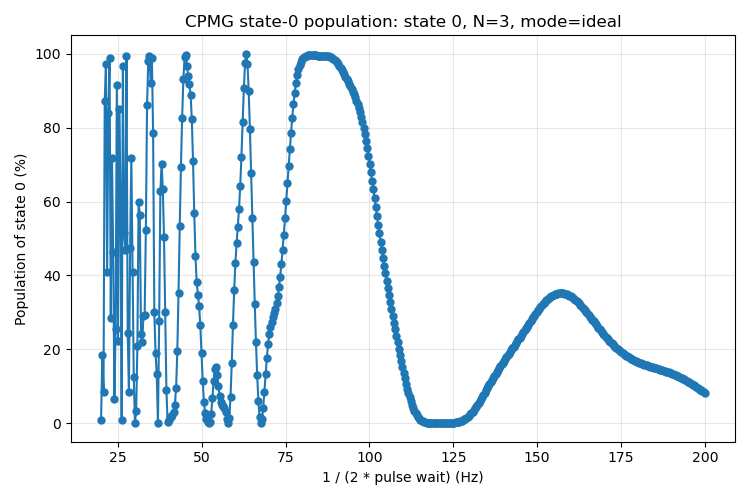

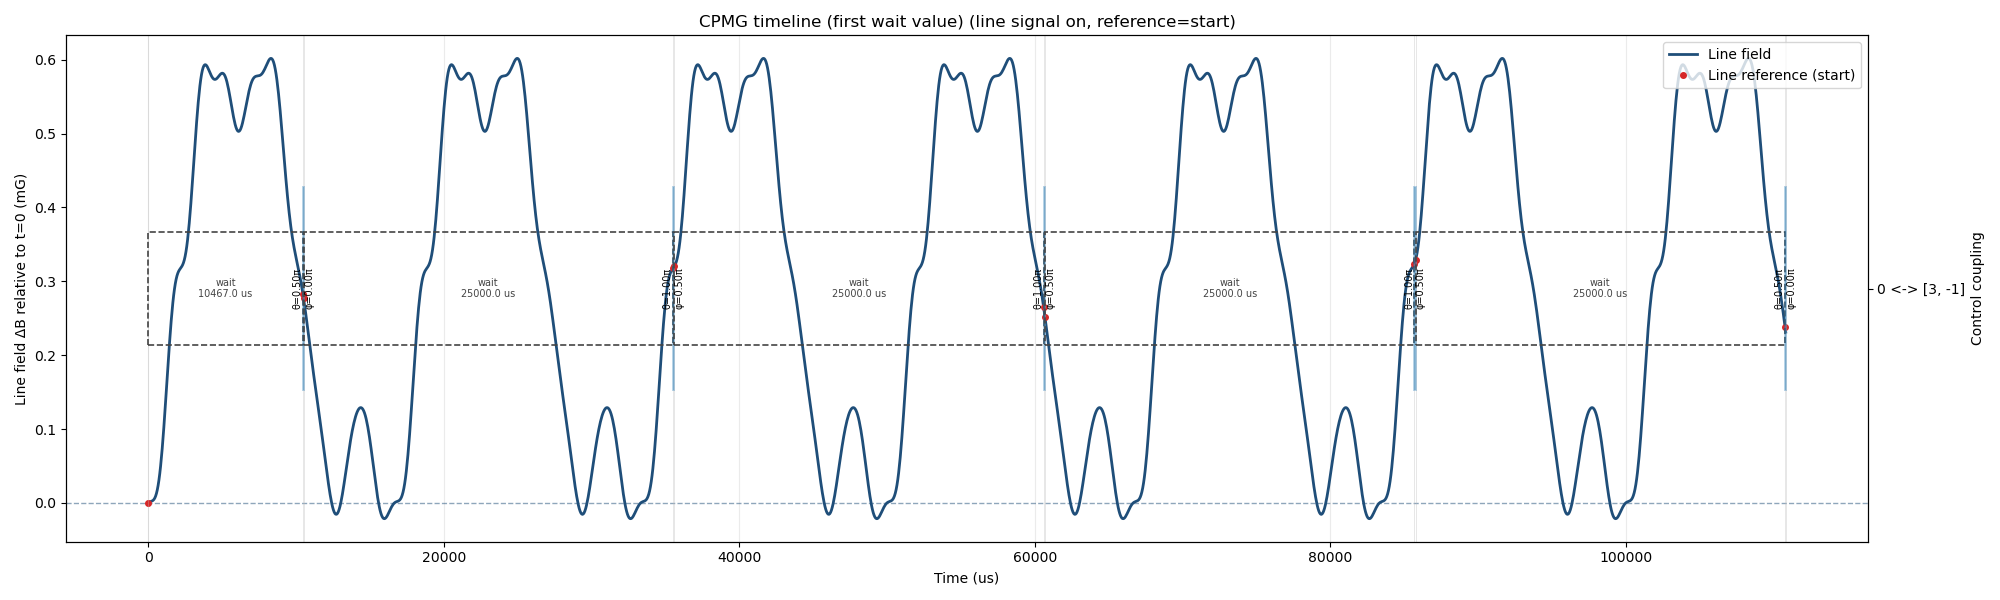

In [33]:
cpmg_sweep_result = run_cpmg_spacing_sweep(
    coupling=cpmg_coupling,
    mappings=mappings,
    dimension=dimension,
    initial_state=initial_state,
    final_pi_half_phase_rad=cpmg_final_pi_half_phase_rad,
    pi_pulse_spacings_us=cpmg_pi_pulse_spacings_us,
    num_pi_pulses=cpmg_num_pi_pulses,
    measured_state_index=cpmg_measured_state_index,
    pi_time_us=cpmg_pi_time_us,
    cpmg_sensitivity_mhz_per_g=cpmg_sensitivity_mhz_per_g,
    initial_pi_half_phase_rad=cpmg_initial_pi_half_phase_rad,
    pi_pulse_phase_rad=cpmg_pi_pulse_phase_rad,
    initial_wait_us=cpmg_initial_wait_us,
    final_frame=wrap_frame(final_frame) if final_frame is not None else None,
    apply_final_frame=apply_final_frame,
    simulation_mode=simulation_mode,
    use_line_signal=use_line_signal,
    line_model=line_model,
    line_reference=line_reference,
    default_pi_time_us=default_pi_time_us,
    pi_time_by_coupling_us=pi_time_by_coupling_us,
    transition_strengths_file=transition_strengths_file,
    sensitivity_matrix_file=sensitivity_matrix_file,
    reference_pi_times_us=reference_pi_times_us,
    reference_strength_indices=reference_strength_indices,
    num_shots=num_shots,
    rng_seed=rng_seed,
    calibration_scale=calibration_scale,
    magnetic_scale=magnetic_scale,
    laser_scale=laser_scale,
    calibration_noise_hwhm_hz=calibration_noise_hwhm_hz,
    calibration_noise_sigma_hz=calibration_noise_sigma_hz,
    magnetic_field_std_g=magnetic_field_std_g,
    laser_gaussian_T_s=laser_gaussian_T_s,
    laser_lorentzian_L_s=laser_lorentzian_L_s,
    voigt_x_min_hz=voigt_x_min_hz,
    voigt_x_max_hz=voigt_x_max_hz,
    voigt_num_points=voigt_num_points,
    rabi_frequency_std_fraction=rabi_frequency_std_fraction,
    line_signal_noise_std_g=line_signal_noise_std_g,
)

print(f"measured_state_label = {cpmg_sweep_result['measured_state_label']}")
print(f"nominal_pi_time_us = {cpmg_sweep_result['nominal_pi_time_us']}")
print(f"final_pi_half_phase_rad = {cpmg_sweep_result['final_pi_half_phase_rad']}")
print(f"simulation_mode = {cpmg_sweep_result['simulation_mode']}")
print(f"use_line_signal = {cpmg_sweep_result['use_line_signal']}")
print("Example CPMG sequence (first wait value):")
display_records(cpmg_sweep_result['sequence_examples']['first']['sequence_steps'])
plot_cpmg_population_vs_wait(cpmg_sweep_result)
plot_sequence_timeline(
    cpmg_sweep_result['prepared_examples']['first'],
    mappings,
    line_model=line_model,
    use_line_signal=use_line_signal,
    line_reference=line_reference,
    title_prefix="CPMG timeline (first wait value)",
)


The CPMG sweep reuses the same deterministic line-signal phase/detuning model and the same Monte Carlo noise knobs as the manual sequence simulation above.

CPMG state-0 population summary


,pulse_wait_us,inverse_half_wait_hz,population_state_0_percent,population_state_0_std_percent
0,10000.000000,50.000000,99.264977,0.0
1,9793.814433,51.052632,98.519705,0.0
2,9595.959596,52.105263,98.825110,0.0
3,9405.940594,53.157895,99.788689,0.0
4,9223.300971,54.210526,99.734024,0.0
5,9047.619048,55.263158,97.474545,0.0
6,8878.504673,56.315789,93.569933,0.0
7,8715.596330,57.368421,89.668710,0.0
8,8558.558559,58.421053,86.980975,0.0
9,8407.079646,59.473684,85.617680,0.0


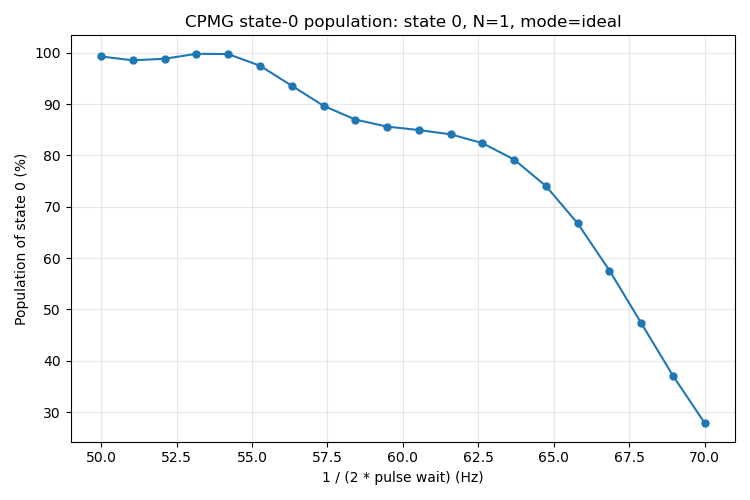

In [19]:
# Directly inspect the simulated population of state 0 across the pulse-wait sweep.
state0_population_records = [
    {
        "pulse_wait_us": float(wait_us),
        "inverse_half_wait_hz": float(freq_hz),
        "population_state_0_percent": float(100.0 * population),
        "population_state_0_std_percent": float(100.0 * population_std),
    }
    for wait_us, freq_hz, population, population_std in zip(
        cpmg_sweep_result['pi_pulse_spacings_us'],
        cpmg_sweep_result['inverse_half_wait_hz'],
        cpmg_sweep_result['measured_state_population'],
        cpmg_sweep_result['measured_state_std'],
    )
]

print("CPMG state-0 population summary")
display_records(state0_population_records)
plot_cpmg_population_vs_wait(cpmg_sweep_result, title_prefix="CPMG state-0 population")


In [20]:
%matplotlib widget

In [21]:
import numpy as np

def make_cpmg_lockin_pulse_table(
    coupling=(0, 1),
    f_target_hz=60.0,
    n_pi=15,
    phi_prepare=0.0,
    phi_pi=np.pi / 2,
    phi_readout=0.0,
    print_table=True,
):
    """
    Build a CPMG / quantum-lock-in pulse table for a trapped-ion two-level subspace.

    Sequence:
        pi/2 - tau - pi - tau - pi - ... - tau - pi/2

    The pi-pulse spacing is:
        tau = 1 / (2 f_target)

    Parameters
    ----------
    coupling : tuple
        Two-state transition being driven, e.g. (0, 1).

    f_target_hz : float
        Target lock-in frequency, e.g. 60 Hz, 120 Hz, 180 Hz.

    n_pi : int
        Number of pi pulses.

    phi_prepare : float
        Phase of initial pi/2 pulse, in radians.

    phi_pi : float
        Phase of CPMG pi pulses, in radians.
        For standard CPMG, pi pulses are often Y pulses, phi_pi = pi/2.
        For simple X-pulse echo train, use phi_pi = 0.

    phi_readout : float
        Phase of final pi/2 pulse, in radians.
        This is the phase you scan experimentally.

    Returns
    -------
    pulses : list of dict
        Pulse table with time, coupling, theta, phi, and wait_after.
    """

    tau = 1.0 / (2.0 * f_target_hz)
    total_time = (n_pi + 1) * tau

    pulses = []

    # Initial pi/2 pulse
    pulses.append({
        "label": "prepare pi/2",
        "time_s": 0.0,
        "coupling": coupling,
        "theta_rad": np.pi / 2,
        "phi_rad": phi_prepare,
        "wait_after_s": tau,
    })

    # CPMG pi pulses
    for k in range(1, n_pi + 1):
        pulses.append({
            "label": f"pi pulse {k}",
            "time_s": k * tau,
            "coupling": coupling,
            "theta_rad": np.pi,
            "phi_rad": phi_pi,
            "wait_after_s": tau,
        })

    # Final readout pi/2 pulse
    pulses.append({
        "label": "readout pi/2",
        "time_s": total_time,
        "coupling": coupling,
        "theta_rad": np.pi / 2,
        "phi_rad": phi_readout,
        "wait_after_s": 0.0,
    })

    if print_table:
        print("CPMG / quantum-lock-in pulse table")
        print("----------------------------------")
        print(f"coupling:              {coupling}")
        print(f"target frequency:      {f_target_hz:.6f} Hz")
        print(f"pi-pulse spacing tau:  {tau * 1e3:.6f} ms")
        print(f"number of pi pulses:   {n_pi}")
        print(f"total sequence time:   {total_time * 1e3:.6f} ms")
        print()
        print(
            f"{'idx':>3} | {'label':>14} | {'time [ms]':>10} | "
            f"{'coupling':>10} | {'theta [rad]':>11} | {'phi [rad]':>9} | "
            f"{'theta/pi':>8} | {'phi/pi':>8} | {'wait after [ms]':>15}"
        )
        print("-" * 116)

        for i, p in enumerate(pulses):
            print(
                f"{i:3d} | "
                f"{p['label']:>14} | "
                f"{p['time_s'] * 1e3:10.6f} | "
                f"{str(p['coupling']):>10} | "
                f"{p['theta_rad']:11.6f} | "
                f"{p['phi_rad']:9.6f} | "
                f"{p['theta_rad'] / np.pi:8.3f} | "
                f"{p['phi_rad'] / np.pi:8.3f} | "
                f"{p['wait_after_s'] * 1e3:15.6f}"
            )

    return pulses

In [11]:
pulses = make_cpmg_lockin_pulse_table(
    coupling=(0, 1),
    f_target_hz=60.0,
    n_pi=15,
    phi_prepare=0.0,
    phi_pi=np.pi / 2,      # Y pi pulses: CPMG-style
    phi_readout=0.0,       # scan this in the experiment
)

CPMG / quantum-lock-in pulse table
----------------------------------
coupling:              (0, 1)
target frequency:      60.000000 Hz
pi-pulse spacing tau:  8.333333 ms
number of pi pulses:   15
total sequence time:   133.333333 ms

idx |          label |  time [ms] |   coupling | theta [rad] | phi [rad] | theta/pi |   phi/pi | wait after [ms]
--------------------------------------------------------------------------------------------------------------------
  0 |   prepare pi/2 |   0.000000 |     (0, 1) |    1.570796 |  0.000000 |    0.500 |    0.000 |        8.333333
  1 |     pi pulse 1 |   8.333333 |     (0, 1) |    3.141593 |  1.570796 |    1.000 |    0.500 |        8.333333
  2 |     pi pulse 2 |  16.666667 |     (0, 1) |    3.141593 |  1.570796 |    1.000 |    0.500 |        8.333333
  3 |     pi pulse 3 |  25.000000 |     (0, 1) |    3.141593 |  1.570796 |    1.000 |    0.500 |        8.333333
  4 |     pi pulse 4 |  33.333333 |     (0, 1) |    3.141593 |  1.570796 |    1.000